## 01. ANOVA One Way, comparando com 3 grupos ou mais

In [1]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_csv('../data/trailers_dados_aulas_1_e_2.csv')
df['tempo_visualizacao'] = df['tempo_visualizacao'].astype(int)
display(df.head())

,trailer_tipo,tempo_visualizacao
0,Drama,104
1,Drama,92
2,Drama,107
3,Drama,125
4,Drama,90


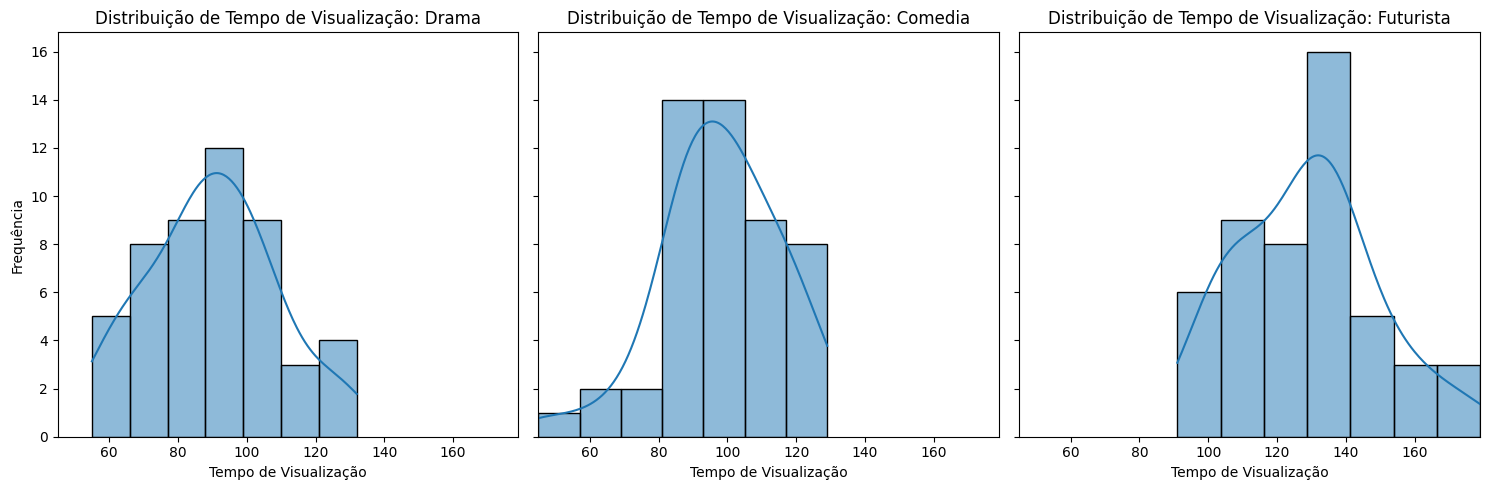

In [3]:
# Analise descritiva
import seaborn as sns
import matplotlib.pyplot as plt


# Mostrar tipos de trailers uncos
trailer_types = df['trailer_tipo'].unique()

# Criar subplots para cada tipo de trailer
fig, axes = plt.subplots(1, len(trailer_types), figsize=(15, 5), sharey=True)

# Plotar a distribuição de tempo de visualização para cada tipo de trailer
for i, trailer_types in enumerate(trailer_types):
    subset_df = df[df['trailer_tipo'] == trailer_types]
    sns.histplot(subset_df['tempo_visualizacao'], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribuição de Tempo de Visualização: {trailer_types}')
    axes[i].set_xlabel('Tempo de Visualização')
    axes[i].set_ylabel('Frequência')

# Ajusar todos  y-axes para ter a mesma escala
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, y_max)

# Ajustar todos x-axes para ter a mesma escala
x_min = df['tempo_visualizacao'].min()
x_max = df['tempo_visualizacao'].max()
for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()


In [4]:
# Agrupar por 'trailer_tipo' e calcular a media, desvio padrão e contagem
stats_table = df.groupby('trailer_tipo')['tempo_visualizacao'].agg(['mean', 'std', 'count']).reset_index()

# Renomear colunas para clareza
stats_table.rename(columns={'mean': 'media', 'std': 'desvio_padrao', 'count': 'numero_observacoes'}, inplace=True)

# Exibir a tabela resultante
display(stats_table)

,trailer_tipo,media,desvio_padrao,numero_observacoes
0,Comedia,97.90,17.521124,50
1,Drama,89.90,18.755407,50
2,Futurista,128.68,20.366479,50



Até aqui exploramos visualmente a distribuição do tempo de visualização por tipo de trailer e calculamos as estatísticas descritivas (média, desvio padrão e tamanho da amostra) para cada grupo, estamos prontos para realizar os cálculos necessários para a **Análise de Variância (ANOVA) One-Way**.

Nos próximos passos, vamos organizar os dados de forma adequada para o teste e, em seguida, executaremos a análise para determinar se há diferenças estatisticamente significativas nas médias de visualização entre os grupos de trailers.

### Estatística F e Distribuição F

A **Estatística F** é a razão entre a variância entre os grupos (MS_between) e a variância dentro dos grupos (MS_within). Ela é calculada usando a seguinte fórmula:

$$ F = \frac{MS_{between}}{MS_{within}} $$

Onde:
*   $ MS_{between} $: Quadrados Médios Entre Grupos
*   $ MS_{within} $: Quadrados Médios Dentro dos Grupos

Se a hipótese nula (de que as médias dos grupos são iguais) for verdadeira, a estatística F calculada seguirá uma **Distribuição F** com $df_{between}$ e $df_{within}$ graus de liberdade. Comparamos a estatística F calculada com os valores da distribuição F para determinar o p-valor.

In [5]:
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
# ANOVA
model = smf.ols('tempo_visualizacao ~ C(trailer_tipo)', data=df).fit()
anova_table = anova.anova_lm(model, typ=2)

print(anova_table)

                       sum_sq     df         F        PR(>F)
C(trailer_tipo)  41921.613333    2.0  58.57436  1.958658e-19
Residual         52603.880000  147.0       NaN           NaN


### Observações ANOVA
*   A linha **`C(trailer_tipo)`** representa a variação **entre os grupos** (between-group). A soma dos quadrados entre os grupos é `41921.613333`.
*   A linha **`Residual`** representa a variação **dentro dos grupos** (within-group). A soma dos quadrados dentro dos grupos é `52603.880000`.

---
### Conclusao
Como o p-valor da ANOVA (1.958658e-19) é muito menor que 0.05, confirmamos que há diferenças estatisticamente significativas entre as médias de tempo de visualização dos grupos de trailers.

---

O código a seguir visualiza a distribuição F teórica esperada sob a hipótese nula e mostra onde a estatística F que você calculou a partir dos seus dados se encaixa nessa distribuição. Se a linha vertical do F calculado estiver na "cauda" direita da distribuição (longe do pico), isso sugere que o seu resultado é improvável de acontecer apenas por acaso, levando a um p-valor pequeno e à rejeição da hipótese nula.

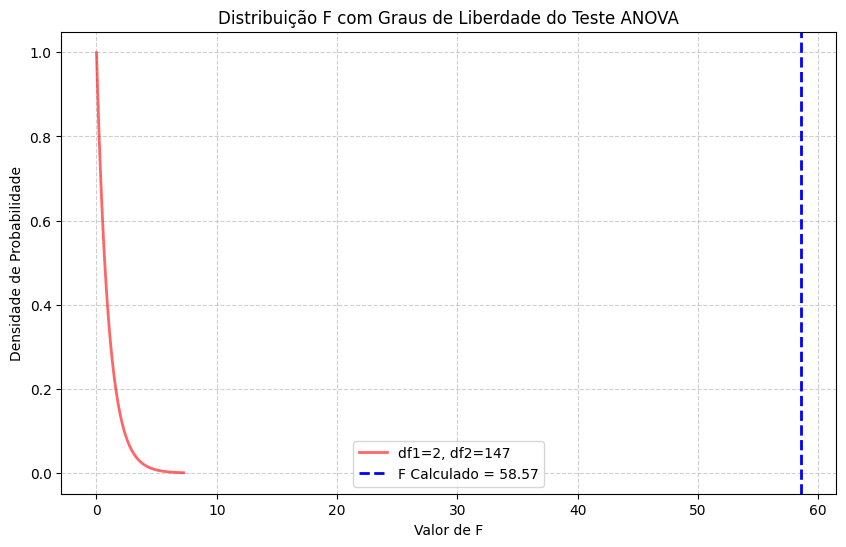

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Degrees of freedom from the ANOVA table
df_between = anova_table.loc['C(trailer_tipo)', 'df']
df_within = anova_table.loc['Residual', 'df']

# Define the range of x values for the plot
x = np.linspace(f.ppf(0.001, df_between, df_within),
                f.ppf(0.999, df_between, df_within), 100)
                
# Plot the F-distribution
plt.figure(figsize=(10, 6))
plt.plot(x, f.pdf(x, df_between, df_within),
         'r-', lw=2, alpha=0.6, label=f'df1={int(df_between)}, df2={int(df_within)}')

# Add a vertical line for the calculated F-statistic
f_calculated = anova_table.loc['C(trailer_tipo)','F']
plt.axvline(f_calculated, color='blue', linestyle='dashed', linewidth=2, label=f'F Calculado = {f_calculated:.2f}')

# Add title and labels
plt.title('Distribuição F com Graus de Liberdade do Teste ANOVA')
plt.xlabel('Valor de F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 02. Téste Pós-HOC: Investigando diferenças específicas

### Teste Pós-Hoc de Tukey HSD

Como a ANOVA One-Way nos indicou que existem diferenças estatisticamente significativas entre as médias de tempo de visualização dos trailers, agora precisamos realizar testes pós-hoc para descobrir **quais pares específicos de grupos são diferentes entre si**.

O **Teste de Tukey Honest Significant Difference (HSD)** é um teste post-hoc comumente utilizado após uma ANOVA significativa. Ele compara as médias de todos os pares possíveis de grupos e ajusta os p-valores para controlar a taxa de erro Tipo I (a chance de declarar uma diferença significativa quando não há) ao fazer múltiplas comparações. Em essência, o Tukey HSD nos ajuda a identificar onde as diferenças reais estão localizadas após uma ANOVA geral.

A estatística do teste de Tukey HSD, frequentemente denotada por 'q', é calculada usando a seguinte fórmula:

$$ q = \frac{\bar{Y}_i - \bar{Y}_j}{\sqrt{\frac{MS_{within}}{n}}} $$

Onde:

*   $ \bar{Y}_i $ e $ \bar{Y}_j $: São as médias dos dois grupos que estão sendo comparados.
*   $ MS_{within} $ (Mean Square Within): É a variância dentro dos grupos, obtida da tabela ANOVA (o valor da linha "Residual" na coluna "MS"). Representa a variação aleatória dentro de cada grupo.
*   $ n $: É o tamanho da amostra em cada grupo. No caso do Tukey HSD "clássico", assume-se que os tamanhos das amostras são iguais em todos os grupos. Se os tamanhos das amostras forem diferentes, é comum usar uma versão modificada da fórmula que usa a média harmônica dos tamanhos das amostras.

A estatística 'q' calculada é então comparada a um valor crítico da distribuição studentized range para determinar se a diferença entre as médias dos grupos é estatisticamente significativa.

### Task
Calcule a estatística do teste de Tukey HSD manualmente e utilizando a função `pairwise_tukeyhsd` da biblioteca `statsmodels`. Compare os resultados e explique o significado de cada elemento na fórmula da estatística 'q'. Explique como encontrar o valor crítico na tabela Studentized Range.

### Calcular estatística 'q' manualmente

### Subtask:
Para cada par de grupos, calcular a estatística 'q' usando a fórmula: $ q = \frac{\bar{Y}_i - \bar{Y}j}{\sqrt{\frac{MS{within}}{n}}} $. Isso envolverá obter as médias dos grupos, o MS_within e o tamanho da amostra.


In [7]:
# Perform Tukey's HSD test using statsmodels
tukey_result = pairwise_tukeyhsd(endog=df['tempo_visualizacao'], groups=df['trailer_tipo'], alpha=0.05)
# Display the results using .summary()
print(tukey_result.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
Comedia     Drama     -8.0 0.0904 -16.9579  0.9579  False
Comedia Futurista    30.78    0.0  21.8221 39.7379   True
  Drama Futurista    38.78    0.0  29.8221 47.7379   True
---------------------------------------------------------



### Insights e observações
Observação1: Para Comedia vs Drama, o intervalo é [-16.9579, 0.9579]. Como este intervalo inclui zero (0 está entre -16.9579 e 0.9579), a diferença não é significativa (reject é False).

Observação2: {meandiff} = {Média do group2} - {Média do group1}

*   As diferenças estatisticamente significativas encontradas indicam que o tipo de trailer (Futurista vs Drama e Futurista vs Comédia) tem um efeito significativo no tempo de visualização. Esse resultado nos direciona para a produção de um filme futurista.

### Teste Pós-Hoc de Bonferroni

O **Teste de Bonferroni** é outro método de teste pós-hoc utilizado após uma ANOVA significativa para controlar a taxa de erro Tipo I ao realizar múltiplas comparações entre pares de grupos.

A correção de Bonferroni é mais simples do que o Tukey HSD. Ela ajusta o nível de significância ($\alpha$) para cada comparação individual dividindo o nível de significância original pelo número total de comparações par a par que estão sendo realizadas.

A fórmula para o novo nível de significância ajustado ($\alpha_{Bonferroni}$) é:

$$ \alpha_{Bonferroni} = \frac{\alpha_{original}}{m} $$

Onde:

*   $ \alpha_{original} $: É o nível de significância original (por exemplo, 0.05).
*   $ m $: É o número total de comparações par a par independentes. Para $k$ grupos, o número de comparações par a par é $ \frac{k(k-1)}{2} $.

Cada comparação individual é então testada para significância usando este novo nível de significância $\alpha_{Bonferroni}$. Se o p-valor de uma comparação for menor que $\alpha_{Bonferroni}$, a diferença é considerada estatisticamente significativa.

O método de Bonferroni é mais conservador (tem menos poder estatístico) do que o Tukey HSD, o que significa que é menos provável encontrar diferenças significativas, especialmente quando há muitas comparações. No entanto, ele é simples de entender e aplicar.

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
import pandas as pd
import scipy.stats as stats

# Assuming 'df' DataFrame is already loaded and contains 'trailer_tipo' and 'tempo_visualizacao'

# Perform pairwise t-tests
groups = df['trailer_tipo'].unique()
p_values = []
comparisons = []

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        data1 = df[df['trailer_tipo'] == group1]['tempo_visualizacao']
        data2 = df[df['trailer_tipo'] == group2]['tempo_visualizacao']

        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(data1, data2)

        p_values.append(p_value)
        comparisons.append(f'{group1} vs {group2}')

# Apply Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')

# Display the results
bonferroni_results = pd.DataFrame({
    'Comparação': comparisons,
    'P-valor Original': p_values,
    'P-valor Corrigido (Bonferroni)': pvals_corrected,
    'Rejeitar H0': reject
})

display(bonferroni_results)

,Comparação,P-valor Original,P-valor Corrigido (Bonferroni),Rejeitar H0
0,Drama vs Comedia,2.986472e-02,8.959417e-02,False
1,Drama vs Futurista,1.953331e-16,5.859993e-16,True
2,Comedia vs Futurista,1.542301e-12,4.626904e-12,True


## 03. ANOVA: medidas repetidas



### Objetivo da Análise

Este notebook tem como objetivo analisar a eficácia de um tratamento para ansiedade, comparando os níveis de escore de um grupo de pacientes em três momentos distintos: no início do tratamento, após 3 meses e após 6 meses. A análise estatística principal será a Análise de Variância (ANOVA) de Medidas Repetidas, complementada por testes post-hoc para identificar diferenças significativas entre os pares de momentos.

### Etapas da Análise

O notebook abordará as seguintes etapas:

1.  **Carregamento e Preparação dos Dados:** Carregar os dados e transformá-los para o formato adequado para a análise (formato 'long').
2.  **Análise Exploratória dos Dados (EDA):** Realizar uma análise descritiva dos dados e visualizar a evolução dos escores de ansiedade ao longo do tempo.
3.  **Cálculo da ANOVA de Medidas Repetidas:** Executar a ANOVA para determinar se há um efeito significativo do tempo no nível de ansiedade.
4.  **Testes Post-Hoc:** Se a ANOVA for significativa, realizar testes post-hoc para identificar quais pares de momentos apresentam diferenças estatisticamente significativas.
5.  **Conclusões:** Interpretar os resultados da ANOVA e dos testes post-hoc e apresentar as conclusões da análise.

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_ansiedade = pd.read_csv('../data/ansiedade_data.csv')
df_ansiedade.head()

,Paciente,inicio,3meses,6meses
0,Paciente 1,31,21,14
1,Paciente 2,29,21,17
2,Paciente 3,32,22,14
3,Paciente 4,28,20,11
4,Paciente 5,28,19,9


In [12]:
# Transformando o DataFrame 'df' para o formato 'long'
# Usando as colunas 'Paciente', 'inicio', '3meses', '6meses'
data_long = pd.melt(df_ansiedade,
                            id_vars=['Paciente'],
                            value_vars=['inicio', '3meses', '6meses'],
                            var_name='Tempo',
                            value_name='Escore_Ansiedade')

# Convertendo a coluna 'Tempo' para o tipo categórico ordenado
data_long['Tempo'] = pd.Categorical(data_long ['Tempo'],
                                            categories=['inicio', '3meses', '6meses'],
                                            ordered=True)

In [18]:
data_long.head()

,Paciente,Tempo,Escore_Ansiedade
0,Paciente 1,inicio,31
1,Paciente 2,inicio,29
2,Paciente 3,inicio,32
3,Paciente 4,inicio,28
4,Paciente 5,inicio,28


In [19]:
print("=== Análise Descritiva ===")
desc_stats_ansiedade = data_long.groupby('Tempo')['Escore_Ansiedade'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
desc_stats_ansiedade

=== Análise Descritiva ===


C:\Users\init\AppData\Local\Temp\ipykernel_19876\926543746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats_ansiedade = data_long.groupby('Tempo')['Escore_Ansiedade'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


,count,mean,median,std,min,max
Tempo,,,,,,
inicio,12,30.250000,31.0,1.602555,28,32
3meses,12,21.583333,21.5,2.391589,18,26
6meses,12,14.083333,14.0,2.778434,9,18


=== Gráfico de Análise Exploratória (Média e Erro Padrão) ===


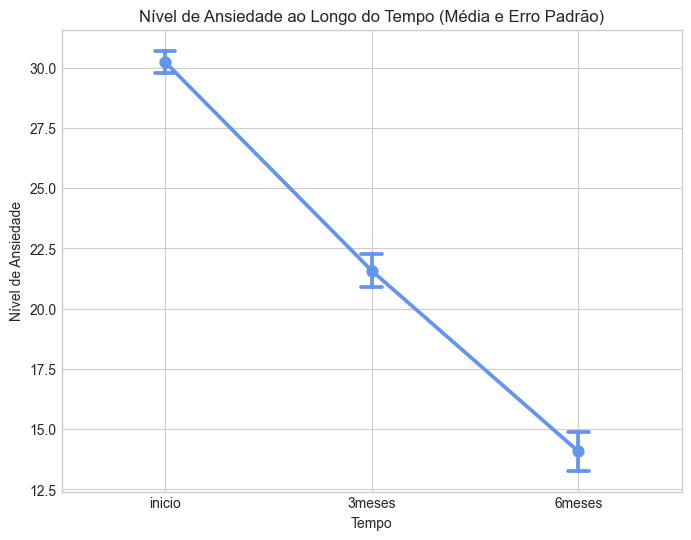

In [20]:
print("=== Gráfico de Análise Exploratória (Média e Erro Padrão) ===")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

# Gráfico de Linha com Média e Erro Padrão
sns.pointplot(
    data=data_long,
    x='Tempo',
    y='Escore_Ansiedade',
    errorbar='se',
    capsize=0.1,
    color='cornflowerblue'
)
plt.title('Nível de Ansiedade ao Longo do Tempo (Média e Erro Padrão)')
plt.ylabel('Nível de Ansiedade')
plt.xlabel('Tempo')
plt.grid(True)
plt.show()

print("\n")

In [21]:
from statsmodels.stats.anova import AnovaRM
print("=== ANOVA de Medidas Repetidas (AnovaRM) ===")

# Usando o DataFrame df_long_ansiedade e os nomes de colunas corretos
aov_stats = AnovaRM(
    data=data_long,
    depvar='Escore_Ansiedade',  # Variável dependente
    subject='Paciente',       # Coluna que identifica os sujeitos
    within=['Tempo'],         # Variável "within-subject" (medidas repetidas)
    aggregate_func='mean'     # Função de agregação, se necessário (geralmente 'mean' para RM ANOVA)
)

model_results = aov_stats.fit()
print(model_results)
print("\n")

=== ANOVA de Medidas Repetidas (AnovaRM) ===
               Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
Tempo 407.1152 2.0000 22.0000 0.0000





O teste de ANOVA de Medidas Repetidas revelou um efeito estatisticamente significativo do tempo nos níveis de escore de ansiedade [F(2, 22) = 407.12, p < 0.001].

Isso significa que há uma diferença significativa nos escores médios de ansiedade observados nos três momentos distintos (Início, 3 meses e 6 meses). Em outras palavras, o tratamento teve um impacto significativo na mudança dos níveis de ansiedade ao longo do tempo.

In [26]:
import pingouin as pg # Inclui diretamente na saída o teste de esfericidade de Mauchly

print("=== ANOVA de Medidas Repetidas (Pingouin) com Teste de Esfericidade ===")

# Usando o DataFrame df_long_ansiedade
aov_pingouin = pg.rm_anova(
    data=data_long,
    dv='Escore_Ansiedade',  # Variável dependente
    within='Tempo',         # Variável "within-subject" (medidas repetidas)
    subject='Paciente',       # Coluna que identifica os sujeitos
    detailed=True,          # Incluir detalhes, como o teste de esfericidade
    effsize='np2'           # Incluir tamanho do efeito (eta-quadrado parcial)
)

display(aov_pingouin)
print("\n")

=== ANOVA de Medidas Repetidas (Pingouin) com Teste de Esfericidade ===


,Source,SS,DF,MS,F,p-unc,np2,eps
0,Tempo,1570.888889,2,785.444444,407.115183,4.178921e-18,0.973691,0.881013
1,Error,42.444444,22,1.929293,NaN,NaN,NaN,NaN


Considerações sobre a Violação da Esfericidade:
 Quando a suposição de esfericidade é violada, o p-valor da ANOVA pode ser inflado, levando a um aumento na chance de um erro Tipo I (rejeitar a hipótese nula quando ela é verdadeira).

  Felizmente, a biblioteca pingouin (e outras como statsmodels) aplica automaticamente correções para lidar com essa violação.
  
  As correções mais comuns é a de Greenhouse-Geisser.
  
  A coluna 'eps' fornece o valor do epsilon de Greenhouse-Geisser, que é usado para ajustar os graus de liberdade da ANOVA e calcular um p-valor corrigido (que geralmente seria mostrado em uma coluna como 'p-GG' ou 'p-HF' se a violação fosse mais severa e a correção fosse aplicada explicitamente no output).
  
  No entanto, com um epsilon de 0.88, a correção de Greenhouse-Geisser é relativamente pequena e o p-valor da ANOVA ainda seria altamente significativo mesmo após a correção.

In [27]:
print("=== Testes Post-Hoc de Tukey ===")

posthoc_tukey = pairwise_tukeyhsd(
    endog=data_long['Escore_Ansiedade'],
    groups=data_long['Tempo'],
    alpha=0.05
)

print(posthoc_tukey)
print("\n")

=== Testes Post-Hoc de Tukey ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
3meses 6meses     -7.5   0.0  -9.814  -5.186   True
3meses inicio   8.6667   0.0  6.3527 10.9807   True
6meses inicio  16.1667   0.0 13.8527 18.4807   True
---------------------------------------------------




Conclusões do teste pós-hoc Tukey:

3 Meses vs 6 Meses: A diferença média nos escores de ansiedade entre 3 meses e 6 meses é de -7.5. O p-valor ajustado (p-adj) é 0.0, o que é menor que o nível de significância de 0.05. A coluna reject é True.


3 Meses vs Inicio: A diferença média nos escores de ansiedade entre 3 meses e Início é de 8.6667. O p-valor ajustado (p-adj) é 0.0, o que é menor que 0.05. A coluna reject é True.

6 Meses vs Inicio: A diferença média nos escores de ansiedade entre 6 meses e Início é de 16.1667. O p-valor ajustado (p-adj) é 0.0, o que é menor que 0.05. A coluna reject é True.

Os testes post-hoc de Tukey indicam que há diferenças estatisticamente significativas nos escores médios de ansiedade entre todos os pares de momentos comparados (Início vs 3 meses, Início vs 6 meses, e 3 meses vs 6 meses). A direção das diferenças mostra uma redução contínua nos escores de ansiedade do Início para 3 meses e de 3 meses para 6 meses.C

## 04. Associação entre variaveis categoricas: Chi Quadrado e Fisher

--------------------------------------------------------------------------
"""
**Objetivo:**
Este notebook tem como objetivo realizar uma análise exploratória e estatística do conjunto de dados de Doenças Cardíacas (UCI Heart Disease) para identificar associações entre variáveis categóricas (Tipo de Dor no Peito, Açúcar no Sangue em Jejum) e a presença de doença cardíaca.

**Passo a Passo:**
1.  **Configuração e Carregamento dos Dados:** Carregar o conjunto de dados a partir de uma URL, definir os nomes das colunas e tratar valores ausentes.
2.  **Limpeza e Preparação dos Dados:** Mapear variáveis categóricas para rótulos mais descritivos para facilitar a interpretação.
3.  **Análise Descritiva das Variáveis de Interesse:** Exibir a distribuição percentual das variáveis categóricas selecionadas.
4.  **Geração de Tabelas de Contingência e Teste de Qui-Quadrado:** Criar tabelas de contingência para examinar a relação entre pares de variáveis categóricas e realizar o teste de Qui-Quadrado para verificar a independência estatística.
5.  **Cálculo de Cramer's V:** Calcular a medida de associação Cramer's V para quantificar a força da associação entre as variáveis categóricas.
6.  **Conclusões:** Interpretar os resultados dos testes estatísticos (Qui-Quadrado e Cramer's V) e fornecer conclusões sobre a associação entre as variáveis.
"""


In [29]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np # Importa numpy para calcular Cramer's V

In [30]:
# Define a URL para o conjunto de dados UCI Heart Disease
# Usaremos uma versão pré-processada e limpa para este exemplo
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Define os nomes das colunas, pois o arquivo não tem cabeçalho
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]


# Carrega os dados em um DataFrame do pandas
df = pd.read_csv(url, names=columns, na_values='?')
print("Dados carregados com sucesso.")

Dados carregados com sucesso.


In [31]:
print(df.shape)
print(df.info())

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [32]:
# As variáveis cp, fbs, e target já são numéricas, mas vamos mapear
# para que a análise descritiva seja mais clara.
print("\nPreparando os dados para análise...")


# A coluna 'target' tem valores 0 e 1, onde 1 significa doença cardíaca presente.
# Vamos mapeá-la para ser mais descritiva.
df['target'] = df['target'].map({0: 'Ausência de Doença', 1: 'Presença de Doença'})

# Mapeia a variável 'cp' (tipo de dor no peito)
cp_mapping = {
    1: 'Angina Típica',
    2: 'Angina Atípica',
    3: 'Dor Não-Angina',
    4: 'Assintomático'
}
df['cp'] = df['cp'].map(cp_mapping)

# Mapeia a variável 'fbs' (açúcar no sangue em jejum)
fbs_mapping = {0: '<= 120 mg/dL', 1: '> 120 mg/dL'}
df['fbs'] = df['fbs'].map(fbs_mapping)

print("Variáveis categóricas mapeadas para rótulos mais descritivos.")


Preparando os dados para análise...
Variáveis categóricas mapeadas para rótulos mais descritivos.


In [33]:
print("\n--- Análise Descritiva das Variáveis ---")

# Análise da variável 'fbs'
print("\n2. Distribuição da variável 'fbs' (Açúcar no Sangue em Jejum > 120 mg/dL):")
print(df['fbs'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Análise da variável 'cp'
print("\n3. Distribuição da variável 'cp' (Tipo de Dor no Peito):")
print(df['cp'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Análise da variável 'target'
print("\n4. Distribuição da variável 'target' (Presença de Doença Cardíaca):")
print(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


--- Análise Descritiva das Variáveis ---

2. Distribuição da variável 'fbs' (Açúcar no Sangue em Jejum > 120 mg/dL):
fbs
<= 120 mg/dL    85.15%
> 120 mg/dL     14.85%
Name: proportion, dtype: object

3. Distribuição da variável 'cp' (Tipo de Dor no Peito):
cp
Assintomático     47.52%
Dor Não-Angina    28.38%
Angina Atípica     16.5%
Angina Típica      7.59%
Name: proportion, dtype: object

4. Distribuição da variável 'target' (Presença de Doença Cardíaca):
target
Ausência de Doença    74.89%
Presença de Doença    25.11%
Name: proportion, dtype: object


C:\Users\init\AppData\Local\Temp\ipykernel_19876\3118939905.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
C:\Users\init\AppData\Local\Temp\ipykernel_19876\3118939905.py:15: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
C:\Users\init\AppData\Local\Temp\ipykernel_19876\3118939905.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='cp', data=df, palette=colors)
C:\Users\init\AppData\Local\Temp\ipykernel_19876\3118939905.py:29: FutureWarning: 

Passing `palette` without a

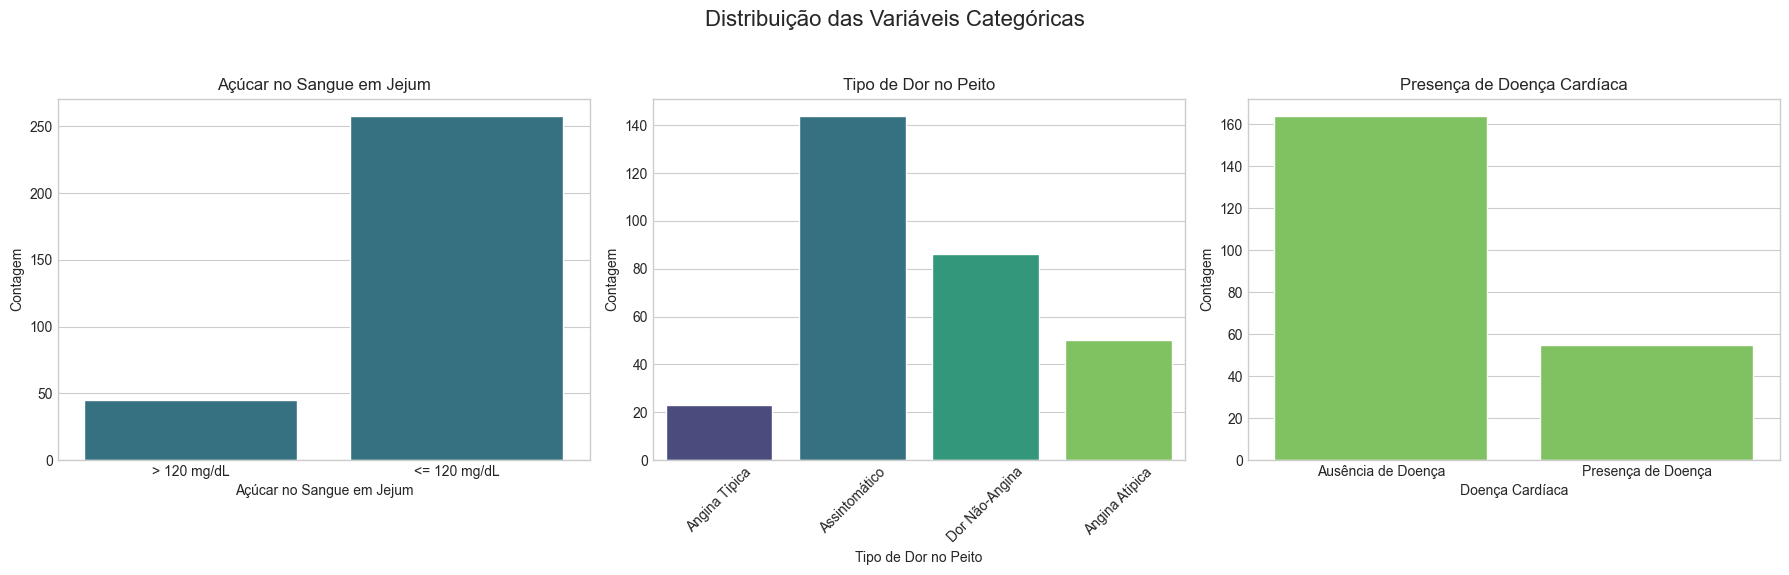

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a paleta de cores
colors = sns.color_palette('viridis', 4)

# Configura o estilo dos gráficos
sns.set_style('whitegrid')

# Cria os subplots para 3 gráficos em uma linha
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Alterado para 1 linha e 3 colunas
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=16)

# Gráfico para 'fbs' (agora no primeiro subplot)
sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
axes[0].set_title('Açúcar no Sangue em Jejum')
axes[0].set_xlabel('Açúcar no Sangue em Jejum')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico para 'cp' (agora no segundo subplot)
sns.countplot(ax=axes[1], x='cp', data=df, palette=colors)
axes[1].set_title('Tipo de Dor no Peito')
axes[1].set_xlabel('Tipo de Dor no Peito')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico para 'target' (agora no terceiro subplot)
sns.countplot(ax=axes[2], x='target', data=df, palette=[colors[3]])
axes[2].set_title('Presença de Doença Cardíaca')
axes[2].set_xlabel('Doença Cardíaca')
axes[2].set_ylabel('Contagem')
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição
plt.show()

In [35]:
# Verificar se há valores ausentes na coluna 'target'
print("Contagem de valores ausentes na coluna 'target':")
print(df['target'].isnull().sum())

# Verificar a distribuição dos valores na coluna 'target', incluindo NaNs se houver
print("\nDistribuição dos valores na coluna 'target' (incluindo NaNs):")
print(df['target'].value_counts(dropna=False))

Contagem de valores ausentes na coluna 'target':
84

Distribuição dos valores na coluna 'target' (incluindo NaNs):
target
Ausência de Doença    164
NaN                    84
Presença de Doença     55
Name: count, dtype: int64


### Geração de Tabelas de Contingência e Teste de Qui-Quadrado e Cramer's V

In [36]:
# Cria a tabela de contingência para 'cp' e 'target' usando pd.crosstab com margens
contingency_table_cp_target = pd.crosstab(df['cp'], df['target'], margins=True)

# Imprime a tabela de contingência
print("Tabela de Contingência (cp e target) com Totais Marginais:")
print(contingency_table_cp_target)

Tabela de Contingência (cp e target) com Totais Marginais:
target          Ausência de Doença  Presença de Doença  All
cp                                                         
Angina Atípica                  41                   6   47
Angina Típica                   16                   5   21
Assintomático                   39                  35   74
Dor Não-Angina                  68                   9   77
All                            164                  55  219


### Cria uma função para teste qui-quadrado: Testar a existência de associação

SyntaxError: 'return' outside function (3699447030.py, line 51)

### Chama a função para testar a associação entre tipo de dor e target

In [40]:
perform_chi2_test(df, 'cp','target')


--- Análise de Associação (Qui-Quadrado) entre cp e target ---

Tabela de Contingência:
target          Ausência de Doença  Presença de Doença
cp                                                    
Angina Atípica                  41                   6
Angina Típica                   16                   5
Assintomático                   39                  35
Dor Não-Angina                  68                   9

Resultados do Teste de Qui-Quadrado:
Estatística Qui-Quadrado (X²): 30.5719
Valor-p (p-value): 0.0000
Graus de Liberdade (dof): 3

Tabela de Frequências Esperadas:
target          Ausência de Doença  Presença de Doença
cp                                                    
Angina Atípica           35.196347           11.803653
Angina Típica            15.726027            5.273973
Assintomático            55.415525           18.584475
Dor Não-Angina           57.662100           19.337900

Conclusão do Teste de Qui-Quadrado:
Existe uma associação estatisticamente significat

(np.float64(30.57194907802423),
 np.float64(1.0460527383618916e-06),
 3,
 array([[35.19634703, 11.80365297],
        [15.7260274 ,  5.2739726 ],
        [55.41552511, 18.58447489],
        [57.66210046, 19.33789954]]))

### Avalia o grau de associação - Cramers V

In [61]:
def calculate_cramers_v(chi2_stat, n, k, r):
    """
    # Calcula o valor de Cramer's V.
    
    # Args:
        chi2_stat (float): A estatística do Qui-Quadrado.
        n (int): O número total de observações.
        k (int): O menor número de linhas ou colunas na tabela de contingência.
        r (int): O maior número de linhas ou colunas na tabela de contingência.
        
    # Returns:
        float: O valor de Cramer's V.
    """
    # Calcula o valor de Cramer's V usando a fórmula:
    # V = sqrt(chi2 / (n * min(k-1, r-1)))
    # Para tabelas 2x2, a fórmula é simplificada
    if k == 2 and r == 2:
        return np.sqrt(chi2_stat / n)
    else:
        return np.sqrt(chi2_stat / (n * (min(k - 1, r - 1))))


# Crie a tabela de contingência para 'cp' e 'target' (sem margens para o teste)
contingency_table_cp_target = pd.crosstab(df['cp'], df['target'], margins=False)

# Obtenha as informações necessárias para Cramer's V
n_observations = contingency_table_cp_target.sum().sum()
num_rows, num_cols = contingency_table_cp_target.shape

# Realize o teste de Qui-Quadrado para obter a estatística 'stat'
stat, p_value, degrees_freedom, expected_freq = chi2_contingency(contingency_table_cp_target)

# Calcule Cramer's V usando a estatística do Qui-Quadrado e as dimensões da tabela
cramers_v_value = calculate_cramers_v(stat, n_observations, num_rows, num_cols)

# Imprimir o valor de Cramer's V
print(f"\nValor de Cramer's V calculado para cp e target: {cramers_v_value:.4f}")


Valor de Cramer's V calculado para cp e target: 0.3736


### Chama a função para testar a associação entre nível de açúcar no sangue e target

In [62]:
perform_chi2_test(df, 'fbs','target')


--- Análise de Associação (Qui-Quadrado) entre fbs e target ---

Tabela de Contingência:
target        Ausência de Doença  Presença de Doença
fbs                                                 
<= 120 mg/dL                 141                  51
> 120 mg/dL                   23                   4

Resultados do Teste de Qui-Quadrado:
Estatística Qui-Quadrado (X²): 1.1685
Valor-p (p-value): 0.2797
Graus de Liberdade (dof): 1

Tabela de Frequências Esperadas:
target        Ausência de Doença  Presença de Doença
fbs                                                 
<= 120 mg/dL          143.780822           48.219178
> 120 mg/dL            20.219178            6.780822

Conclusão do Teste de Qui-Quadrado:
Não há evidência de associação estatisticamente significativa entre fbs e target (p = 0.2797).
Não rejeitamos a hipótese nula de independência.


## 05. Correlação: Pearson, Spearman e Kendall